In [2]:
import pandas as pd
import numpy as np
import scipy.io as scio
import mat73
import os
import sys
from tqdm import tqdm
from collections import defaultdict
import openpyxl 
import dill
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance
import importlib
import helper_function as hf
importlib.reload(hf)
# import plotting_functions as pf
# importlib.reload(pf)

2026-05-05 09:58:35,010 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2026-05-05 09:58:35,015 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2026-05-05 09:58:35,015 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 



<module 'helper_function' from '/lisc/data/scratch/neurobiology/zimmer/jalaja/Manuscript/codes/neuronal_data_analyses/Fig6/helper_function.py'>

In [3]:
#IMPORT data from matlab files
dd= pd.read_csv("/lisc/data/scratch/neurobiology/zimmer/jalaja/imaging/newline/cleaned/for_BundleNet/deltaFoF_alldataset.csv", delimiter=',',parse_dates=True)
dd.columns=dd.columns.str.strip("''")
dd

,AIBL,AIBR,AIZL,ALA,ALNL,ALNR,AQR,AS10,ASKL,ASKR,...,URYVR,VA01,VA11,VA12,VB01,VB02,VD13,target,state,group
0,0.387170,0.097740,0.312340,0.145770,NaN,0.95588,-0.11433,0.003151,1.35830,0.554600,...,0.073543,0.12440,NaN,NaN,0.62955,0.098488,0.015532,2,1,1
1,0.418530,0.069665,0.267290,0.128760,NaN,0.92111,-0.13575,-0.015684,1.27280,0.570670,...,0.046784,0.12474,NaN,NaN,0.61028,0.084541,0.013973,2,1,1
2,0.448780,0.051929,0.239980,0.105750,NaN,0.87986,-0.14115,-0.037594,1.16260,0.580160,...,0.033031,0.12504,NaN,NaN,0.57180,0.079309,-0.002591,2,1,1
3,0.477770,0.045791,0.232590,0.076009,NaN,0.83133,-0.12856,-0.062951,1.02460,0.582280,...,0.033870,0.12532,NaN,NaN,0.51179,0.083855,-0.035988,2,1,1
4,0.475250,0.053608,0.209490,0.073328,NaN,0.85503,-0.13928,-0.052906,0.95813,0.536360,...,0.039577,0.13207,NaN,NaN,0.51291,0.082970,-0.007096,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85045,-0.100090,-0.123270,-0.091191,-0.339340,-0.35703,-0.48824,-0.22803,NaN,-0.19723,-0.132620,...,-0.126310,NaN,-0.052055,0.103360,-0.18571,-0.098487,0.198120,2,1,9
85046,-0.086111,-0.106290,-0.089964,-0.339710,-0.34738,-0.48779,-0.20283,NaN,-0.19967,-0.128080,...,-0.127810,NaN,-0.058894,0.097431,-0.19207,-0.100030,0.206260,2,1,9
85047,-0.089498,-0.134590,-0.097088,-0.355450,-0.33665,-0.49817,-0.20000,NaN,-0.19820,-0.117480,...,-0.114520,NaN,-0.066565,0.095080,-0.20473,-0.103260,0.214000,2,1,9
85048,-0.090512,-0.149300,-0.092970,-0.346930,-0.33888,-0.49830,-0.20349,NaN,-0.20218,-0.108090,...,-0.120090,NaN,-0.053817,0.091680,-0.20745,-0.111210,0.203250,2,1,9


In [3]:
dd.columns

Index(['AIBL', 'AIBR', 'AIZL', 'ALA', 'ALNL', 'ALNR', 'AQR', 'AS10', 'ASKL',
       'ASKR', 'AUAL', 'AUAR', 'AVAL', 'AVAR', 'AVEL', 'AVER', 'BAGL', 'BAGR',
       'DA01', 'DA07', 'DA09', 'DB01', 'DB02', 'DB07', 'DVA', 'IL2L', 'IL2R',
       'PQR', 'PVNL', 'PVNR', 'PVPL', 'RIBL', 'RIBR', 'RID', 'RIML', 'RIMR',
       'RIS', 'RIVL', 'RIVR', 'RMGL', 'RMGR', 'SIADL', 'SIADR', 'SMBDL',
       'SMBDR', 'SMBVL', 'SMDDL', 'SMDDR', 'SMDVL', 'SMDVR', 'URXL', 'URXR',
       'URYDL', 'URYDR', 'URYVL', 'URYVR', 'VA01', 'VA11', 'VA12', 'VB01',
       'VB02', 'VD13', 'target', 'state', 'group'],
      dtype='object')

In [4]:
#Normalize scaling
fps = 5
X=dd.drop({'target','state','group'},axis=1)

scaled_datasets_X = []

for n in range(1, 10):
# for n in range(0, 9):
    # robust_scaler=RobustScaler()
    robust_scaler=RobustScaler(with_centering=False, with_scaling=True, quantile_range=(5, 95))
    # scaled_data_X = robust_scaler.fit_transform(X.loc[n*9450:(n+1)*9450-1,:])
    # scaled_data_X = robust_scaler.fit_transform(X.loc[n*9450:(n*9450)+(450*fps),:])
    group_data=X[dd['group'] == n]
    scaled_data_X =robust_scaler.fit_transform(group_data)
    scaled_datasets_X.append(scaled_data_X)

# Concatenate scaled datasets from each group
scaled_X_within_group = np.concatenate(scaled_datasets_X)

# Scale across all groups
scaled_X_across_groups = robust_scaler.fit_transform(scaled_X_within_group)
scaled_X=pd.DataFrame(data=scaled_X_across_groups,columns=X.columns) 


normalized_data = pd.DataFrame(data=np.c_[scaled_X, dd['target'],dd['state'],dd['group']],columns=dd.columns)
normalized_data.columns=normalized_data.columns.str.strip("''")

/lisc/data/scratch/neurobiology/zimmer/jalaja/conda/envs/jupyter/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/lisc/data/scratch/neurobiology/zimmer/jalaja/conda/envs/jupyter/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/lisc/data/scratch/neurobiology/zimmer/jalaja/conda/envs/jupyter/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/lisc/data/scratch/neurobiology/zimmer/jalaja/conda/envs/jupyter/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/lisc/data/scratch/neurobiology/zimmer/jalaja/conda/envs/jupyter/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._u

In [4]:
#Imputing the missing values using ppca, this computation takes a while on server, if the connect is poor, skip to the next step
dk=hf.impute_missing_values_in_dataframe(normalized_data.drop({'target','state','group'}, axis=1))
df = pd.DataFrame(data=np.c_[dk, dd['target'],dd['state'],dd['group']],columns=dd.columns)

/lisc/data/scratch/neurobiology/zimmer/jalaja/conda/envs/jupyter/lib/python3.8/site-packages/ppca/_ppca.py:82: RuntimeWarning: divide by zero encountered in log
  det = np.log(np.linalg.det(Sx))


In [4]:
#sometimes the server connection is poor that it get stuck at this step and can not proceed :( In that case, I skip and use the saved version of the output.
df=pd.read_csv("/lisc/data/scratch/neurobiology/zimmer/jalaja/imaging/newline/cleaned/for_BundleNet/deltaFoF_alldataset_normalized_imputed.csv",index_col=0)

In [5]:
df

,AIBL,AIBR,AIZL,ALA,ALNL,ALNR,AQR,AS10,ASKL,ASKR,...,URYVR,VA01,VA11,VA12,VB01,VB02,VD13,target,state,group
0,0.521373,0.338425,1.826822,0.679138,1.403746,2.058831,-0.104627,0.032247,2.816749,1.524430,...,0.395375,0.503693,0.266641,0.141658,0.876496,0.560253,0.029447,2.0,forward,1.0
1,0.563603,0.241216,1.563332,0.599889,1.332696,1.983941,-0.124230,-0.160488,2.639445,1.568602,...,0.251516,0.505069,0.191877,0.072465,0.849667,0.480915,0.026491,2.0,forward,1.0
2,0.604338,0.179805,1.403601,0.492686,1.262545,1.895095,-0.129171,-0.384684,2.410920,1.594687,...,0.177578,0.506284,0.118385,0.009567,0.796093,0.451153,-0.004911,2.0,forward,1.0
3,0.643377,0.158552,1.360378,0.354123,1.193422,1.790568,-0.117650,-0.644152,2.124745,1.600514,...,0.182089,0.507418,0.046311,-0.046262,0.712544,0.477013,-0.068229,2.0,forward,1.0
4,0.639983,0.185618,1.225270,0.341633,1.177231,1.841614,-0.127460,-0.541366,1.986904,1.474294,...,0.212770,0.534748,0.049446,-0.044076,0.714103,0.471979,-0.013453,2.0,forward,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85045,-0.337189,-0.292141,-0.299399,-0.538693,-0.445803,-0.393887,-0.168692,0.038079,-0.553895,-0.332820,...,-0.666183,-0.413719,-0.202737,0.296801,-0.433082,-0.504517,0.409849,2.0,forward,9.0
85046,-0.290096,-0.251899,-0.295371,-0.539281,-0.433754,-0.393524,-0.150049,0.021986,-0.560747,-0.321427,...,-0.674094,-0.412997,-0.229372,0.279775,-0.447914,-0.512421,0.426688,2.0,forward,9.0
85047,-0.301506,-0.318968,-0.318760,-0.564267,-0.420356,-0.401898,-0.147956,0.047024,-0.556619,-0.294825,...,-0.604000,-0.397928,-0.259248,0.273024,-0.477438,-0.528968,0.442700,2.0,forward,9.0
85048,-0.304922,-0.353830,-0.305240,-0.550742,-0.423140,-0.402003,-0.150537,0.053759,-0.567796,-0.271260,...,-0.633378,-0.409660,-0.209599,0.263261,-0.483781,-0.569693,0.420461,2.0,forward,9.0


In [6]:
# create triggered traces
    # Parameters
interval_start = 450 # start at 390 seconds
interval_step = 90  # interval of 90 seconds
slice_duration = 60  # slice the prestimulus 60 seconds
stimulus_period=30
fps = 5  # frames per second

# Create the new sliced DataFrame
sliced_df , triggered_df= hf.create_sliced_dataframe(df, interval_start, interval_step, slice_duration,stimulus_period, fps)
print(triggered_df)

           AIBL      AIBR      AIZL       ALA      ALNL      ALNR       AQR  \
1950  -0.094824 -0.217878  0.184700  0.120034 -0.081424 -0.088127 -0.179028   
1951  -0.110536 -0.190337  0.286791  0.166274 -0.078709 -0.099859 -0.177335   
1952  -0.134139 -0.223906  0.468883  0.192919 -0.046717 -0.079025 -0.166188   
1953  -0.146769 -0.214049  0.405821  0.175186 -0.061139 -0.082980 -0.159709   
1954  -0.151994 -0.212231  0.349227  0.121012 -0.073902 -0.088885 -0.157248   
...         ...       ...       ...       ...       ...       ...       ...   
84745 -0.193335 -0.149014 -0.433187 -0.575205 -0.370885 -0.418549  0.128359   
84746 -0.190115 -0.148246 -0.462112 -0.574776 -0.371959 -0.413273  0.119607   
84747 -0.256239 -0.221332 -0.418839 -0.564712 -0.370073 -0.409078  0.130127   
84748 -0.287589 -0.221732 -0.427375 -0.572840 -0.358885 -0.420332  0.117765   
84749 -0.298909 -0.191950 -0.457121 -0.586460 -0.343839 -0.436055  0.097051   

           AS10      ASKL      ASKR  ...     URYVR 

In [7]:
# Drop rows where 'target' is 2
triggered_df_forPLS = triggered_df[triggered_df['target'] != 2]

In [8]:
df_pls=pd.DataFrame(data=sliced_df)
# Drop rows where 'target_vector' is 2
sliced_df_forPLS = df_pls[df_pls['target'] != 2]
pls_X=triggered_df_forPLS.drop({'target','state','group'},axis=1)
pls_x=sliced_df_forPLS.drop({'target','state','group'},axis=1)
motor_neurons={'DB01','DB02','DB07','VB01','VB02','AS10','DA01','DA07','DA09','VA01','VA11','VA12','VD13','target','state','group'}
exclude={'ASKR','BAGL','URXR','VB01','SMBDL','SIADL','AVAL','AIBL','SMDVL','RIML','RIMR','ALNL','SMDVR','DB02','RIVL','DA09','URYVR','AVAR','AQR','VA01','URYDL','AUAL','AVEL','DA07','IL2R','target','state','group'}
pls_x_nomotor=df_pls.drop(exclude,axis=1)
y=sliced_df_forPLS['target']
groups=sliced_df_forPLS['group']

In [9]:
sliced_df_forPLS

,AIBL,AIBR,AIZL,ALA,ALNL,ALNR,AQR,AS10,ASKL,ASKR,...,URYVR,VA01,VA11,VA12,VB01,VB02,VD13,target,state,group
1950,-0.094824,-0.217878,0.184700,0.120034,-0.081424,-0.088127,-0.179028,0.048798,-0.381857,-0.193498,...,0.089227,0.230937,0.057746,0.048603,0.025565,0.108640,0.130131,1.0,forward,1.0
1951,-0.110536,-0.190337,0.286791,0.166274,-0.078709,-0.099859,-0.177335,-0.003445,-0.377813,-0.168803,...,0.095883,0.249996,0.048787,0.051961,0.018205,0.035495,0.125531,1.0,forward,1.0
1952,-0.134139,-0.223906,0.468883,0.192919,-0.046717,-0.079025,-0.166188,-0.017896,-0.376320,-0.147954,...,0.178686,0.288656,0.053818,0.071949,0.032728,0.125501,0.120870,1.0,forward,1.0
1953,-0.146769,-0.214049,0.405821,0.175186,-0.061139,-0.082980,-0.159709,0.069470,-0.356848,-0.108461,...,0.083593,0.239525,0.056699,0.070349,0.035679,0.197757,0.106755,1.0,forward,1.0
1954,-0.151994,-0.212231,0.349227,0.121012,-0.073902,-0.088885,-0.157248,0.086811,-0.338246,-0.086963,...,-0.000800,0.188974,0.048788,0.054712,0.034816,0.243703,0.091305,1.0,forward,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84595,-0.178135,-0.335060,-0.234720,-0.475655,-0.372221,-0.418581,-0.153378,0.130294,-0.152379,0.012007,...,-0.486713,-0.314873,-0.049692,0.215252,-0.368555,-0.480779,0.558112,0.0,forward,9.0
84596,-0.178108,-0.332287,-0.210152,-0.473305,-0.364866,-0.414185,-0.151884,0.121195,-0.187023,0.013359,...,-0.427294,-0.314779,-0.085239,0.192820,-0.388587,-0.513600,0.548658,0.0,forward,9.0
84597,-0.208563,-0.330841,-0.292698,-0.492498,-0.380524,-0.430553,-0.159555,0.096743,-0.234774,-0.076547,...,-0.291499,-0.312607,-0.168939,0.180599,-0.416012,-0.552122,0.597645,0.0,forward,9.0
84598,-0.232825,-0.306455,-0.287665,-0.495085,-0.388753,-0.430441,-0.163491,0.092396,-0.310521,-0.119471,...,-0.392178,-0.313658,-0.141984,0.177968,-0.415172,-0.541006,0.590053,0.0,forward,9.0


In [10]:
from sklearn.cross_decomposition import PLSCanonical
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=5)
#pls.fit(pls_x_nomotor, y)
pls.fit(pls_x,y)
#opls= PLSCanonical(n_components=1)
#opls.fit(pls_x,y)
# pls.fit(pc,y) 

PLSRegression(n_components=5)

In [11]:
pls.score(pls_x,y)

0.26181268935925306

In [12]:
after_pls_df=pd.DataFrame(data=np.c_[pls.transform(pls_X),triggered_df_forPLS['target'],triggered_df_forPLS['group'],triggered_df_forPLS['state']],columns=['PLS1','PLS2','PLS3','PLS4','PLS5','target','group','state'])

In [13]:
n=450
Y=after_pls_df['target']
PLS1_df = pd.DataFrame(index=range(117), columns=range(n+1))
PLS2_df = pd.DataFrame(index=range(117), columns=range(n+1))
PLS3_df = pd.DataFrame(index=range(117), columns=range(n+1))
PLS4_df = pd.DataFrame(index=range(117), columns=range(n+1))
PLS5_df = pd.DataFrame(index=range(117), columns=range(n+1))

for i in range(0,117):
    row_index = (i * n)
    PLS1_df.iloc[i, :-1] = after_pls_df.iloc[row_index:row_index + n, 0]
    PLS2_df.iloc[i, :-1] = after_pls_df.iloc[row_index:row_index + n, 1]
    PLS3_df.iloc[i, :-1] = after_pls_df.iloc[row_index:row_index + n, 2]
    


    PLS1_df.iloc[i, -1] = Y[row_index]  # Assign the last value of the window to the last column
    PLS2_df.iloc[i, -1] = Y[row_index]
    PLS3_df.iloc[i, -1] = Y[row_index]
   

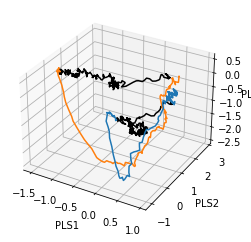

In [14]:
hit_mean_PLS1 = PLS1_df[PLS1_df.iloc[:, -1] == 1].mean()
hit_std_PLS1=PLS1_df[PLS1_df.iloc[:, -1] == 1].std()
miss_mean_PLS1 = PLS1_df[PLS1_df.iloc[:, -1] == 0].mean()
miss_std_PLS1=PLS1_df[PLS1_df.iloc[:, -1] == 0].std()
hit_mean_PLS2 = PLS2_df[PLS1_df.iloc[:, -1] == 1].mean()
hit_std_PLS2=PLS2_df[PLS1_df.iloc[:, -1] == 1].std()
miss_mean_PLS2 = PLS2_df[PLS1_df.iloc[:, -1] == 0].mean()
miss_std_PLS2=PLS2_df[PLS1_df.iloc[:, -1] == 0].std()
hit_mean_PLS3 = PLS3_df[PLS1_df.iloc[:, -1] == 1].mean()
hit_std_PLS3=PLS3_df[PLS1_df.iloc[:, -1] == 1].std()
miss_mean_PLS3 = PLS3_df[PLS1_df.iloc[:, -1] == 0].mean()
miss_std_PLS3=PLS3_df[PLS1_df.iloc[:, -1] == 0].std()

time=np.linspace(-60,30,n)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
#
# # Plot lines for hit data
ax.plot(hit_mean_PLS1[0:301], hit_mean_PLS2[0:301], hit_mean_PLS3[0:301], c='black')
ax.plot(miss_mean_PLS1[0:301], miss_mean_PLS2[0:301], miss_mean_PLS3[0:301], c='black')
ax.plot(hit_mean_PLS1[300:-1], hit_mean_PLS2[300:-1], hit_mean_PLS3[300:-1], c='#ff7f0eff')
ax.plot(miss_mean_PLS1[300:-1], miss_mean_PLS2[300:-1], miss_mean_PLS3[300:-1], c='#1f77b4ff')
ax.set_xlabel('PLS1')
ax.set_ylabel('PLS2')
ax.set_zlabel('PLS3')
plt.show()


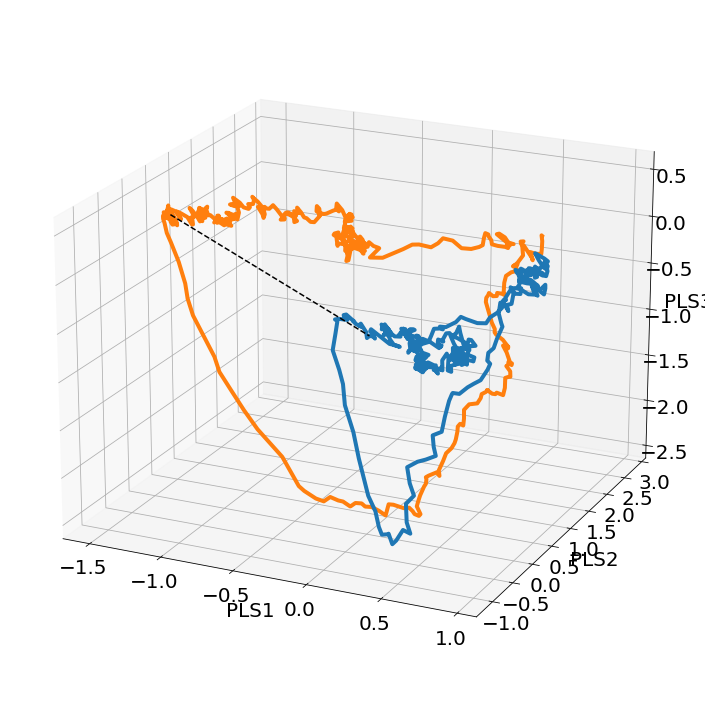

In [26]:
# Create figure with maximum size and for manuscript
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot hit and miss trajectories
ax.plot(hit_mean_PLS1[:-1], hit_mean_PLS2[:-1], hit_mean_PLS3[:-1], 
        color=(1.0, 0.498, 0.055, 1.0), linewidth=4, label='Hit')
ax.plot(miss_mean_PLS1[:-1], miss_mean_PLS2[:-1], miss_mean_PLS3[:-1], 
        color=(0.122, 0.467, 0.706, 1.0), linewidth=4, label='Miss')

# Coordinates of the 300th point
hit_300 = (hit_mean_PLS1[300], hit_mean_PLS2[300], hit_mean_PLS3[300])
miss_300 = (miss_mean_PLS1[300], miss_mean_PLS2[300], miss_mean_PLS3[300])

# Plot a dotted line connecting the 300th points of both lines
ax.plot([hit_300[0], miss_300[0]], 
        [hit_300[1], miss_300[1]], 
        [hit_300[2], miss_300[2]], 'k--')

# Set labels and tick properties
ax.set_xlabel('PLS1', fontsize=20)
ax.set_ylabel('PLS2', fontsize=20)
ax.set_zlabel('PLS3', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=20)

# Keep default 3D view (do NOT set ax.view_init)
ax.view_init(elev=20, azim=-65)  # This is default, so we remove it

# Adjust layout
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

plt.rcParams['svg.fonttype'] = 'none'
# Save as high-resolution SVG file
# plt.savefig('PLS_3d_plot.svg', format='svg', dpi=300, bbox_inches='tight')

# Show plot
plt.show()


In [16]:
# Define the columns to smooth
columns_to_smooth = PLS1_df.columns

# Apply the smoothing function, here simple moving average
PLS1_smooth = hf.smooth_data(PLS1_df, columns_to_smooth, window=10)
PLS2_smooth = hf.smooth_data(PLS2_df, columns_to_smooth, window=10)
PLS3_smooth = hf.smooth_data(PLS3_df, columns_to_smooth, window=10)


In [17]:
df_pls_x=sliced_df_forPLS.drop({'state'},axis=1)
df_pls_X=triggered_df_forPLS.drop({'state'},axis=1)

In [18]:
# Plot the first component, highlight top 10 neurons
df_loadings = pf.plot_pls_loadings(pls, pls_x, component=0, top_n=10)

NameError: name 'pf' is not defined

In [19]:
np.sum(abs(pls.x_loadings_[:,0]))

9.011049406208652

In [20]:
lda = LinearDiscriminantAnalysis()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=None)
# cv_scores = cross_val_score(lda,pls_df_for_lda_stim, pls_y, scoring='accuracy', cv=cv, groups=pls_groups, n_jobs=-1)
cv_scores=cross_val_score(lda,pls_x, y, scoring='accuracy', cv=cv, n_jobs=-1)
cv_scores

array([0.7519943 , 0.74458689, 0.74088319, 0.74102564, 0.747151  ])

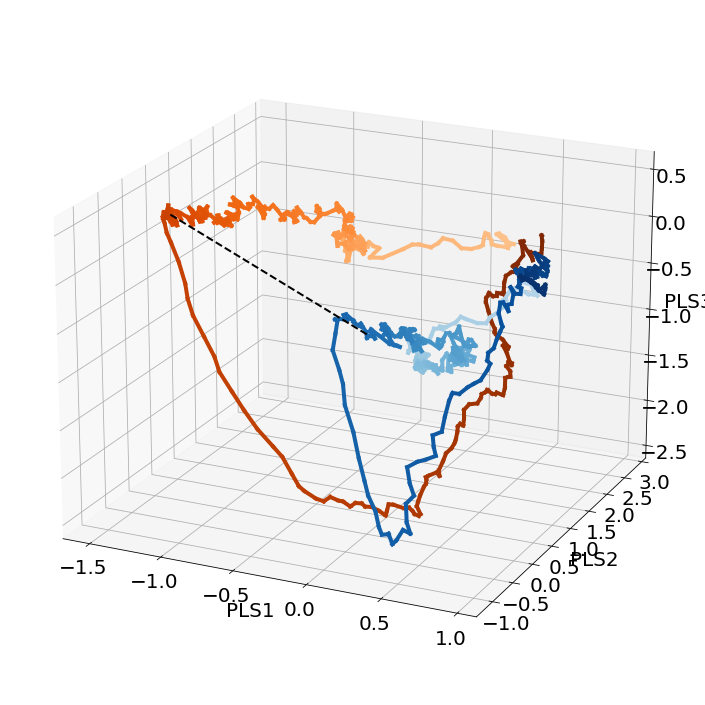

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# -----------------------------------
# Remove last point (same as your [:-1])
# -----------------------------------

hit_x = hit_mean_PLS1[:-1]
hit_y = hit_mean_PLS2[:-1]
hit_z = hit_mean_PLS3[:-1]

miss_x = miss_mean_PLS1[:-1]
miss_y = miss_mean_PLS2[:-1]
miss_z = miss_mean_PLS3[:-1]

n = len(hit_x)

# -----------------------------------
# Same palette style for time gradient
# -----------------------------------

hit_colors = cm.Oranges(np.linspace(0.3, 1, n))
miss_colors = cm.Blues(np.linspace(0.3, 1, n))

# -----------------------------------
# Plot Hit trace with color gradient
# -----------------------------------

for i in range(n - 1):
    ax.plot(
        hit_x[i:i+2],
        hit_y[i:i+2],
        hit_z[i:i+2],
        color=hit_colors[i],
        linewidth=4
    )

# -----------------------------------
# Plot Miss trace with color gradient
# -----------------------------------

for i in range(n - 1):
    ax.plot(
        miss_x[i:i+2],
        miss_y[i:i+2],
        miss_z[i:i+2],
        color=miss_colors[i],
        linewidth=4
    )

# -----------------------------------
# Coordinates of the 300th point
# -----------------------------------

hit_300 = (hit_x[300], hit_y[300], hit_z[300])
miss_300 = (miss_x[300], miss_y[300], miss_z[300])

# -----------------------------------
# Dotted line connecting 300th points
# -----------------------------------

ax.plot(
    [hit_300[0], miss_300[0]],
    [hit_300[1], miss_300[1]],
    [hit_300[2], miss_300[2]],
    'k--',
    linewidth=2
)

# -----------------------------------
# Labels
# -----------------------------------

ax.set_xlabel('PLS1', fontsize=20)
ax.set_ylabel('PLS2', fontsize=20)
ax.set_zlabel('PLS3', fontsize=20)

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=20)

# same view as yours
ax.view_init(elev=20, azim=-65)

plt.subplots_adjust(
    left=0.1,
    right=0.9,
    top=0.9,
    bottom=0.1
)
plt.rcParams['svg.fonttype'] = 'none'
# Save as high-resolution SVG file
# plt.savefig('PLS_3d_plot_time_aligned.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()

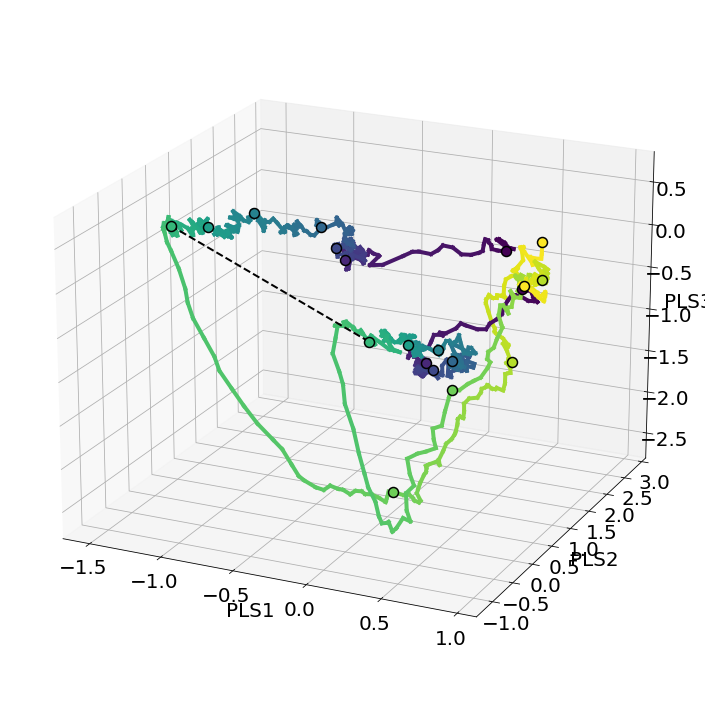

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# -----------------------------------
# Remove last point (same as your [:-1])
# -----------------------------------

hit_x = hit_mean_PLS1[:-1]
hit_y = hit_mean_PLS2[:-1]
hit_z = hit_mean_PLS3[:-1]

miss_x = miss_mean_PLS1[:-1]
miss_y = miss_mean_PLS2[:-1]
miss_z = miss_mean_PLS3[:-1]

n = len(hit_x)

# -----------------------------------
# Time settings
# fps = 5
# Assume frame 300 = 0 sec (stimulus time)
# -----------------------------------

fps = 5
stim_idx = 300

# Relative time: frame 300 becomes 0 sec
time_seconds = (np.arange(n) - stim_idx) / fps

# -----------------------------------
# Same colormap for both traces
# -----------------------------------

cmap = cm.viridis
norm = Normalize(vmin=-60, vmax=30)

colors = cmap(norm(time_seconds))

# -----------------------------------
# Plot Hit trace with color gradient
# -----------------------------------

for i in range(n - 1):
    ax.plot(
        hit_x[i:i+2],
        hit_y[i:i+2],
        hit_z[i:i+2],
        color=colors[i],
        linewidth=4
    )

# -----------------------------------
# Plot Miss trace with same color gradient
# -----------------------------------

for i in range(n - 1):
    ax.plot(
        miss_x[i:i+2],
        miss_y[i:i+2],
        miss_z[i:i+2],
        color=colors[i],
        linewidth=4
    )

# -----------------------------------
# Add dots every 10 sec
# (-60, -50, ..., 20, 30)
# -----------------------------------

dot_times = np.arange(-60, 31, 10)

for t in dot_times:
    idx = stim_idx + int(t * fps)

    if idx >= n:
        idx = n - 1   # force last available point

    if idx >= 0:
        ax.scatter(
            hit_x[idx],
            hit_y[idx],
            hit_z[idx],
            color=colors[idx],
            s=100,
            edgecolor='black',
            linewidth=1.5
        )

        ax.scatter(
            miss_x[idx],
            miss_y[idx],
            miss_z[idx],
            color=colors[idx],
            s=100,
            edgecolor='black',
            linewidth=1.5
        )

# -----------------------------------
# Dotted line connecting frame 300
# -----------------------------------

hit_300 = (hit_x[stim_idx], hit_y[stim_idx], hit_z[stim_idx])
miss_300 = (miss_x[stim_idx], miss_y[stim_idx], miss_z[stim_idx])

ax.plot(
    [hit_300[0], miss_300[0]],
    [hit_300[1], miss_300[1]],
    [hit_300[2], miss_300[2]],
    'k--',
    linewidth=2
)

# -----------------------------------
# Labels
# -----------------------------------

ax.set_xlabel('PLS1', fontsize=20)
ax.set_ylabel('PLS2', fontsize=20)
ax.set_zlabel('PLS3', fontsize=20)

ax.tick_params(axis='both', which='major', labelsize=20)

ax.view_init(elev=20, azim=-65)

# -----------------------------------
# Colorbar
# Ticks from -60 to 30 sec
# -----------------------------------

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7)

# cbar.set_ticks(np.arange(-60, 31, 10))
# cbar.set_label('Time (s)', fontsize=18)
# cbar.ax.tick_params(labelsize=14)

# Keep default 3D view (do NOT set ax.view_init)
ax.view_init(elev=20, azim=-65)  # This is default, so we remove it

# Adjust layout
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.rcParams['svg.fonttype'] = 'none'
# Save as high-resolution SVG file
plt.savefig('PLS_3d_plot_time_aligned.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()

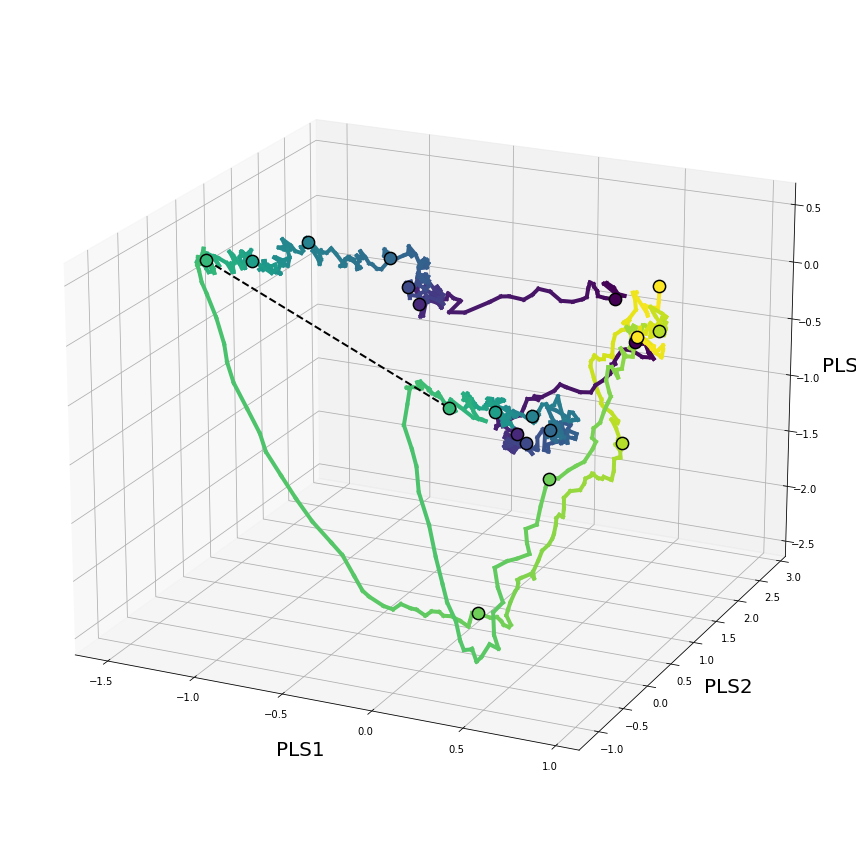

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# -----------------------------------
# Remove last point
# -----------------------------------

hit_x = hit_mean_PLS1[:-1]
hit_y = hit_mean_PLS2[:-1]
hit_z = hit_mean_PLS3[:-1]

miss_x = miss_mean_PLS1[:-1]
miss_y = miss_mean_PLS2[:-1]
miss_z = miss_mean_PLS3[:-1]

n = len(hit_x)

# -----------------------------------
# Time settings
# -----------------------------------

fps = 5
stim_idx = 300
time_seconds = (np.arange(n) - stim_idx) / fps

# -----------------------------------
# Colormap
# -----------------------------------

cmap = cm.viridis
norm = Normalize(vmin=-60, vmax=30)
colors = cmap(norm(time_seconds))

# -----------------------------------
# Plot Hit trace (colored)
# -----------------------------------

for i in range(n - 1):
    ax.plot(
        hit_x[i:i+2],
        hit_y[i:i+2],
        hit_z[i:i+2],
        color=colors[i],
        linewidth=4
    )

# -----------------------------------
# Plot Miss trace (colored)
# -----------------------------------

for i in range(n - 1):
    ax.plot(
        miss_x[i:i+2],
        miss_y[i:i+2],
        miss_z[i:i+2],
        color=colors[i],
        linewidth=4
    )

# -----------------------------------
# Dots every 10 sec
# -----------------------------------

dot_times = np.arange(-60, 31, 10)

for t in dot_times:
    idx = stim_idx + int(t * fps)

    if idx >= n:
        idx = n - 1

    if idx >= 0:
        ax.scatter(
            hit_x[idx], hit_y[idx], hit_z[idx],
            color=colors[idx],
            s=150,
            edgecolor='black',
            linewidth=1.5
        )

        ax.scatter(
            miss_x[idx], miss_y[idx], miss_z[idx],
            color=colors[idx],
            s=150,
            edgecolor='black',
            linewidth=1.5
        )

# -----------------------------------
# Dotted line at stimulus frame
# -----------------------------------

hit_300 = (hit_x[stim_idx], hit_y[stim_idx], hit_z[stim_idx])
miss_300 = (miss_x[stim_idx], miss_y[stim_idx], miss_z[stim_idx])

ax.plot(
    [hit_300[0], miss_300[0]],
    [hit_300[1], miss_300[1]],
    [hit_300[2], miss_300[2]],
    linestyle='--',
    linewidth=2,
    color='black'
)

# -----------------------------------
# FORCE IDENTICAL AXIS LIMITS
# (CRITICAL for comparison)
# -----------------------------------

all_x = np.concatenate([hit_x, miss_x])
all_y = np.concatenate([hit_y, miss_y])
all_z = np.concatenate([hit_z, miss_z])

# ax.set_xlim(all_x.min(), all_x.max())
# ax.set_ylim(all_y.min(), all_y.max())
ax.set_zlim(all_z.min(), all_z.max())


# Labels
ax.set_xlabel('PLS1', fontsize=20, labelpad=15)
ax.set_ylabel('PLS2', fontsize=20, labelpad=15)
ax.set_zlabel('PLS3', fontsize=20, labelpad=15)

# Ticks
# ax.tick_params(axis='both', which='major', labelsize=20, pad=8)

# View (FIXED for reproducibility)
ax.view_init(elev=20, azim=-65)

# -----------------------------------
# Colorbar (optional)
# -----------------------------------

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Uncomment if needed
# cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7)
# cbar.set_ticks(np.arange(-60, 31, 10))
# cbar.set_label('Time (s)', fontsize=18)
# cbar.ax.tick_params(labelsize=14)

# -----------------------------------
# Layout + Save
# -----------------------------------

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(
    'PLS_3d_plot_time_aligned.svg',
    format='svg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

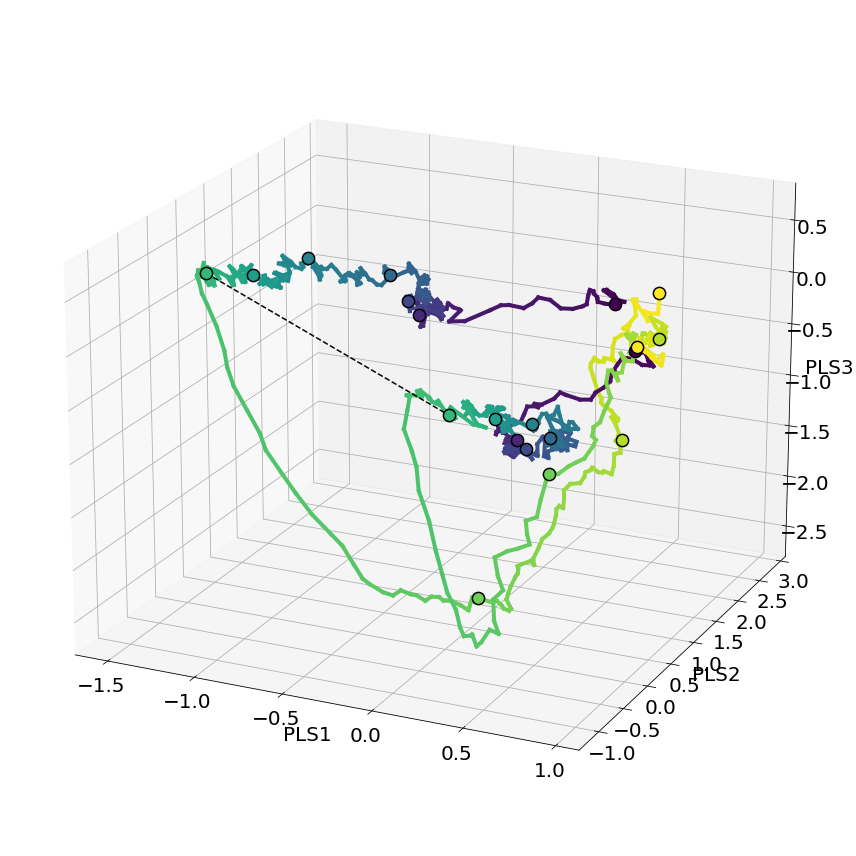

In [35]:
# Create figure with maximum size and for manuscript
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

for i in range(n - 1):
    ax.plot(
        hit_x[i:i+2],
        hit_y[i:i+2],
        hit_z[i:i+2],
        color=colors[i],
        linewidth=4
    )

# -----------------------------------
# Plot Miss trace (colored)
# -----------------------------------

for i in range(n - 1):
    ax.plot(
        miss_x[i:i+2],
        miss_y[i:i+2],
        miss_z[i:i+2],
        color=colors[i],
        linewidth=4
    )

# -----------------------------------
# Dots every 10 sec
# -----------------------------------

dot_times = np.arange(-60, 31, 10)

for t in dot_times:
    idx = stim_idx + int(t * fps)

    if idx >= n:
        idx = n - 1

    if idx >= 0:
        ax.scatter(
            hit_x[idx], hit_y[idx], hit_z[idx],
            color=colors[idx],
            s=150,
            edgecolor='black',
            linewidth=1.5
        )

        ax.scatter(
            miss_x[idx], miss_y[idx], miss_z[idx],
            color=colors[idx],
            s=150,
            edgecolor='black',
            linewidth=1.5
        )

# Coordinates of the 300th point
hit_300 = (hit_mean_PLS1[300], hit_mean_PLS2[300], hit_mean_PLS3[300])
miss_300 = (miss_mean_PLS1[300], miss_mean_PLS2[300], miss_mean_PLS3[300])

# Plot a dotted line connecting the 300th points of both lines
ax.plot([hit_300[0], miss_300[0]], 
        [hit_300[1], miss_300[1]], 
        [hit_300[2], miss_300[2]], 'k--')

# Set labels and tick properties
ax.set_xlabel('PLS1', fontsize=20)
ax.set_ylabel('PLS2', fontsize=20)
ax.set_zlabel('PLS3', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=20)

# Keep default 3D view (do NOT set ax.view_init)
ax.view_init(elev=20, azim=-65)  # This is default, so we remove it

# Adjust layout
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(
    'PLS_3d_plot_time_aligned.svg',
    format='svg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()